In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)

print("Setup terminé ✓")

Setup terminé ✓


In [2]:
def direction(joueur):
    """Blanc avance vers les indices croissants (+1), Noir vers les decroissants (-1)."""
    return 1 if joueur == "blanc" else -1

def zone_bear_off(joueur):
    """Indices de la zone finale : Blanc = 18-23 (points 19-24), Noir = 0-5 (points 1-6)."""
    return range(18, 24) if joueur == "blanc" else range(0, 6)

def signe(joueur):
    """Blanc = pions positifs, Noir = pions negatifs."""
    return 1 if joueur == "blanc" else -1

def case_entree_barre(joueur, de):
    """
    Point d'entree depuis la barre.
    Blanc rentre dans la zone 1-6 (indices 0-5) : de=1 -> indice 0
    Noir rentre dans la zone 19-24 (indices 18-23) : de=1 -> indice 23
    """
    if joueur == "blanc":
        return de - 1
    return 24 - de

In [3]:
def coups_legaux(board, de, joueur, bar_joueur):
    """
    Retourne la liste des coups legaux (depart, arrivee) pour UNE valeur de de.
    depart = -1 signifie "depuis la barre"
    arrivee = -1 signifie "sortie du plateau" (bear off)
    """
    coups = []
    d = direction(joueur)
    s = signe(joueur)
    
    # PRIORITE ABSOLUE : si un pion est sur la barre, il doit rentrer avant tout
    if bar_joueur > 0:
        case_entree = case_entree_barre(joueur, de)
        if board[case_entree] * s >= -1:
            coups.append((-1, case_entree))
        return coups
    
    # Verifier si le bear off est autorise (tous les pions dans la zone finale)
    zone = zone_bear_off(joueur)
    pions_hors_zone = 0
    for i in range(24):
        if i not in zone and board[i] * s > 0:
            pions_hors_zone += abs(board[i])
    peut_sortir = (pions_hors_zone == 0)
    
    for case_depart in range(24):
        # On ne bouge que SES propres pions
        if board[case_depart] * s <= 0:
            continue
        
        case_arrivee = case_depart + d * de
        
        # Cas 1 : le coup sort du plateau -> bear off potentiel
        if case_arrivee < 0 or case_arrivee > 23:
            if peut_sortir:
                # Verifier qu'aucun pion plus eloigne du bord de sortie ne pourrait utiliser ce de
                pion_plus_loin = False
                if joueur == "blanc":
                    for i in range(18, case_depart):
                        if board[i] > 0:
                            pion_plus_loin = True
                else:
                    for i in range(case_depart + 1, 6):
                        if board[i] < 0:
                            pion_plus_loin = True
                
                # Sortie exacte toujours autorisee, sortie surdimensionnee seulement si pas de pion plus loin
                distance_exacte = (23 - case_depart + 1) if joueur == "blanc" else (case_depart + 1)
                if de == distance_exacte or (de > distance_exacte and not pion_plus_loin):
                    coups.append((case_depart, -1))
            continue
        
        # Cas 2 : deplacement normal — la case d'arrivee doit avoir au plus 1 pion adverse
        if board[case_arrivee] * s >= -1:
            coups.append((case_depart, case_arrivee))
    
    return coups

In [4]:
def coups_legaux_tour(board, des, joueur, bar_joueur):
    """Genere toutes les sequences de coups legales pour un tour complet (2 ou 4 des)."""
    s = signe(joueur)
    
    def explorer(board_actuel, bar_actuel, des_restants):
        if not des_restants:
            return [[]]
        
        sequences = []
        de = des_restants[0]
        autres_des = des_restants[1:]
        coups_possibles = coups_legaux(board_actuel, de, joueur, bar_actuel)
        
        if not coups_possibles:
            return explorer(board_actuel, bar_actuel, autres_des)
        
        for (depart, arrivee) in coups_possibles:
            nb = board_actuel.copy()
            nouvelle_bar = bar_actuel
            
            if depart == -1:
                nouvelle_bar -= 1
            else:
                nb[depart] -= s
            
            if arrivee != -1:
                if nb[arrivee] * s == -1:   # capture d'un pion adverse isole
                    nb[arrivee] = 0
                nb[arrivee] += s
            
            suites = explorer(nb, nouvelle_bar, autres_des)
            for suite in suites:
                sequences.append([(depart, arrivee, de)] + suite)
        
        return sequences
    
    toutes = explorer(board, bar_joueur, des)
    if not toutes:
        return []
    longueur_max = max(len(x) for x in toutes)
    return [x for x in toutes if len(x) == longueur_max]

In [5]:
class BackgammonEnv:
    def __init__(self, n_pions=3):
        self.n_points = 24
        self.n_pions = n_pions
        self.reset()
    
    def reset(self):
        self.board = np.zeros(self.n_points)
        self.bar_blanc = 0
        self.bar_noir = 0
        self.sortis_blanc = 0
        self.sortis_noir = 0
        self.joueur_actuel = "blanc"
        
        self.board[0] = 1    # point 1
        self.board[1] = 1    # point 2
        self.board[2] = 1    # point 3
        
        self.board[23] = -1  # point 24
        self.board[22] = -1  # point 23
        self.board[21] = -1  # point 22
        
        return self._get_state()
    
    def _get_state(self):
        return {
            "board": self.board.copy(),
            "bar_blanc": self.bar_blanc,
            "bar_noir": self.bar_noir,
            "sortis_blanc": self.sortis_blanc,
            "sortis_noir": self.sortis_noir,
            "joueur_actuel": self.joueur_actuel
        }
    
    def bar_du_joueur(self, joueur):
        return self.bar_blanc if joueur == "blanc" else self.bar_noir
    
    def coups_disponibles(self, des):
        return coups_legaux_tour(self.board, des, self.joueur_actuel,
                                 self.bar_du_joueur(self.joueur_actuel))
    
    def jouer_coup(self, depart, arrivee):
        j = self.joueur_actuel
        s = signe(j)
        
        if depart == -1:
            if j == "blanc":
                self.bar_blanc -= 1
            else:
                self.bar_noir -= 1
        else:
            self.board[depart] -= s
        
        if arrivee == -1:
            if j == "blanc":
                self.sortis_blanc += 1
            else:
                self.sortis_noir += 1
            return
        
        if self.board[arrivee] * s == -1:  # capture
            self.board[arrivee] = 0
            if j == "blanc":
                self.bar_noir += 1
            else:
                self.bar_blanc += 1
        
        self.board[arrivee] += s
    
    def changer_joueur(self):
        self.joueur_actuel = "noir" if self.joueur_actuel == "blanc" else "blanc"
    
    def partie_terminee(self):
        if self.sortis_blanc == self.n_pions:
            return "blanc"
        if self.sortis_noir == self.n_pions:
            return "noir"
        return None

In [6]:
def verifier_invariant(env):
    n_blanc = np.sum(env.board[env.board > 0]) + env.bar_blanc + env.sortis_blanc
    n_noir = np.sum(np.abs(env.board[env.board < 0])) + env.bar_noir + env.sortis_noir
    assert n_blanc == env.n_pions, f"Erreur : {n_blanc} pions blancs au lieu de {env.n_pions}"
    assert n_noir == env.n_pions, f"Erreur : {n_noir} pions noirs au lieu de {env.n_pions}"

In [7]:
def lancer_des():
    de1 = np.random.randint(1, 7)
    de2 = np.random.randint(1, 7)
    if de1 == de2:
        return [de1, de1, de1, de1]
    return [de1, de2]

In [8]:
def afficher_plateau(env):
    board = env.board
    fig, ax = plt.subplots(figsize=(9, 5))
    
    grand_cadre = patches.Rectangle((-0.7, -0.7), 15.4, 8.4, facecolor="none", edgecolor="black", linewidth=2)
    ax.add_patch(grand_cadre)
    
    for coords in [(0, 4), (7, 4), (7, 0), (0, 0)]:
        rect = patches.Rectangle(coords, 6, 3, facecolor="none", edgecolor="black", linewidth=1)
        ax.add_patch(rect)
    
    ax.plot([6.5, 6.5], [-0.3, 7.3], color="black", linewidth=1.5)
    
    for i in range(24):
        if i <= 5:
            x = 12 - i; y_base = 0; direction_y = 1
        elif i <= 11:
            x = 11 - i; y_base = 0; direction_y = 1
        elif i <= 17:
            x = i - 12; y_base = 7; direction_y = -1
        else:
            x = i - 11; y_base = 7; direction_y = -1
        
        triangle = patches.Polygon(
            [(x, y_base), (x + 1, y_base), (x + 0.5, y_base + direction_y * 3)],
            closed=True, facecolor="none", edgecolor="black", linewidth=0.8
        )
        ax.add_patch(triangle)
        
        ax.text(x + 0.5, y_base + direction_y * 0.2, str(i + 1), fontsize=7, ha='center', color="gray")
        
        n = int(board[i])
        couleur_pion = "white" if n > 0 else "black"
        for p in range(abs(n)):
            y_pion = y_base + direction_y * (0.65 + p * 0.55)
            cercle = patches.Circle((x + 0.5, y_pion), 0.22, facecolor=couleur_pion, edgecolor="black", linewidth=0.8)
            ax.add_patch(cercle)
    
    ax.set_xlim(-1, 15)
    ax.set_ylim(-1.2, 8.2)
    ax.set_aspect('equal')
    ax.axis('off')
    titre = (f"Tour : {env.joueur_actuel}  |  Barre B/N : {env.bar_blanc}/{env.bar_noir}"
             f"  |  Sortis B/N : {env.sortis_blanc}/{env.sortis_noir}")
    ax.set_title(titre, fontsize=10)
    plt.tight_layout()
    return fig, ax


=== Tour 1 — blanc — dés : [4, 5] ===
Séquence jouée : [(2, 6, 4), (1, 6, 5)]


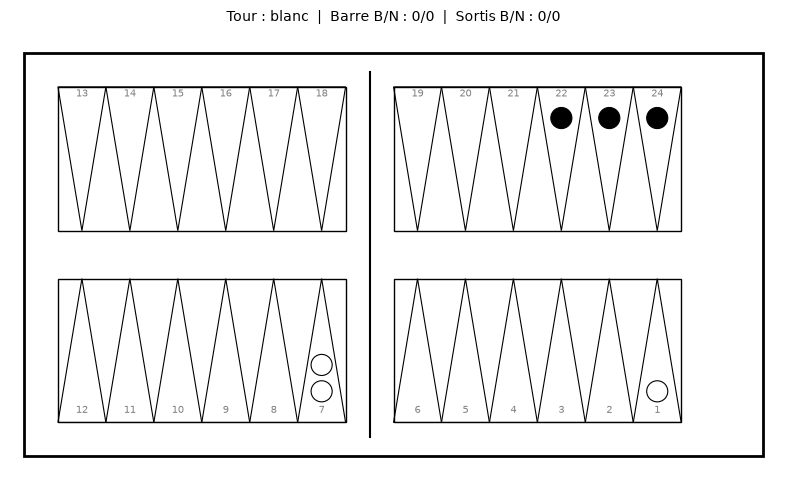


=== Tour 2 — noir — dés : [5, 5, 5, 5] ===
Séquence jouée : [(22, 17, 5), (17, 12, 5), (21, 16, 5), (12, 7, 5)]


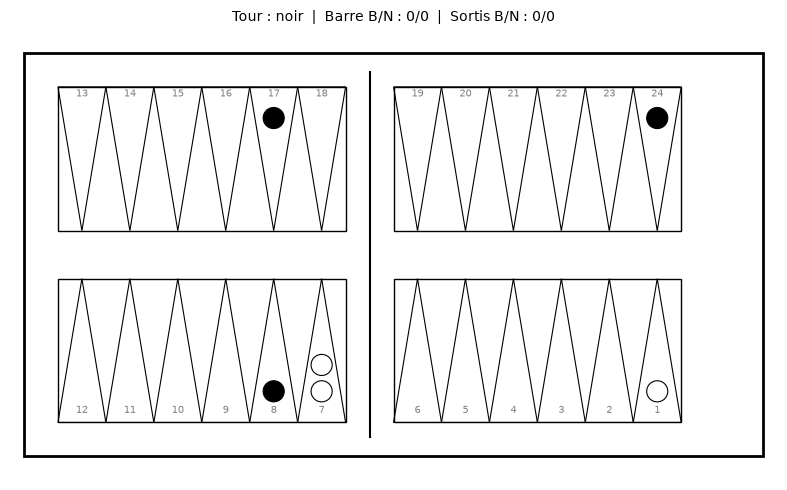


=== Tour 3 — blanc — dés : [3, 6] ===
Séquence jouée : [(6, 9, 3), (9, 15, 6)]


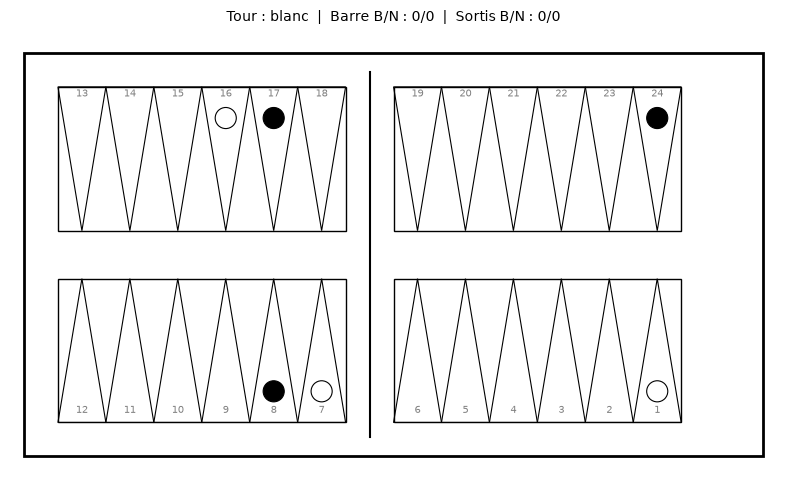


=== Tour 4 — noir — dés : [2, 4] ===
Séquence jouée : [(16, 14, 2), (23, 19, 4)]


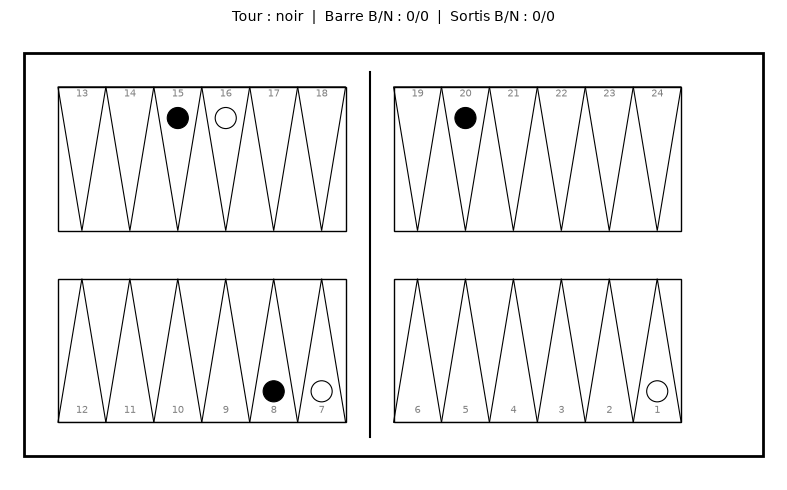


=== Tour 5 — blanc — dés : [2, 4] ===
Séquence jouée : [(6, 8, 2), (8, 12, 4)]


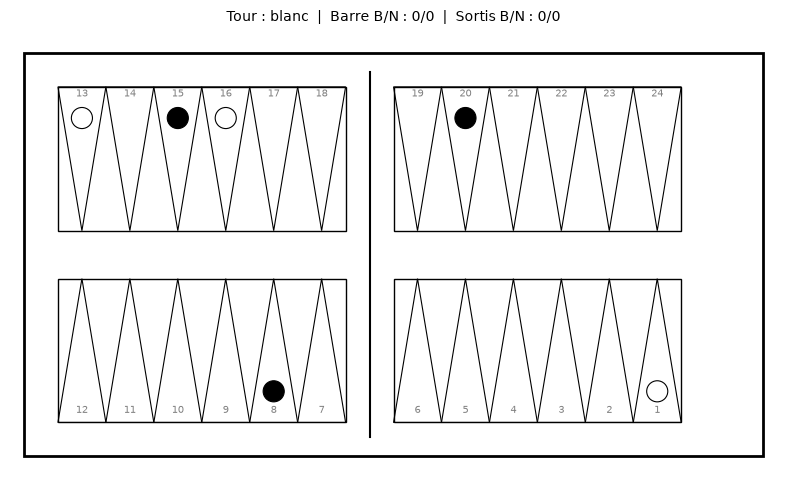


=== Tour 6 — noir — dés : [1, 4] ===
Séquence jouée : [(14, 13, 1), (19, 15, 4)]


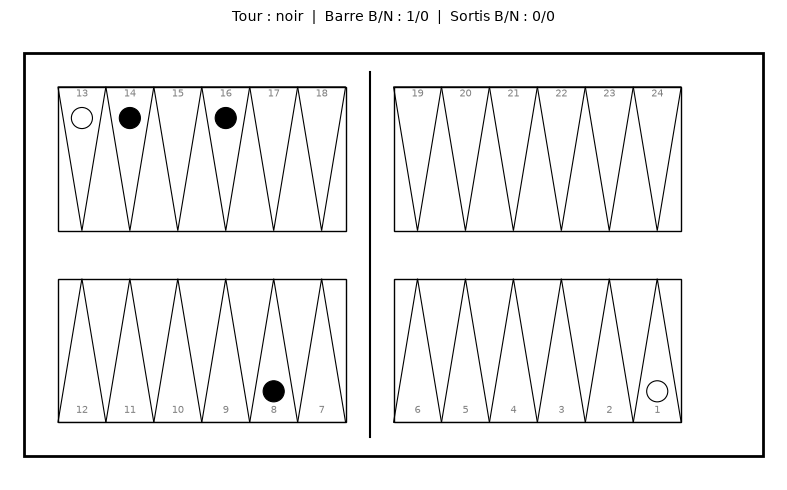


=== Tour 7 — blanc — dés : [5, 4] ===
Séquence jouée : [(-1, 4, 5), (0, 4, 4)]


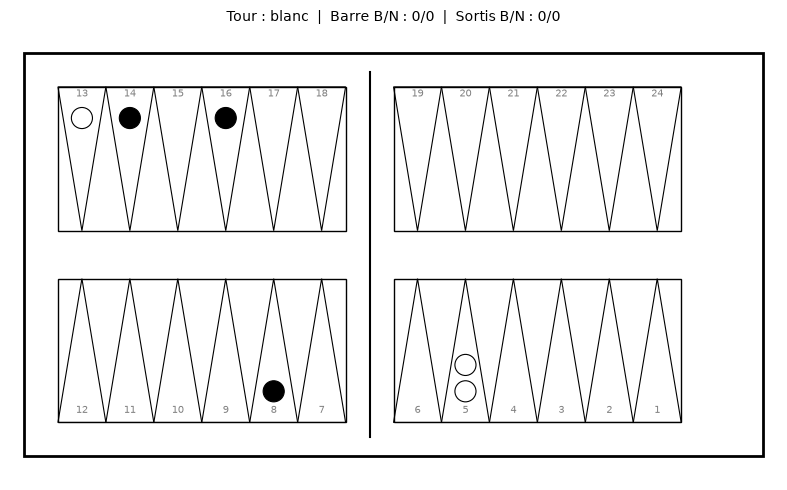


=== Tour 8 — noir — dés : [1, 3] ===
Séquence jouée : [(7, 6, 1), (15, 12, 3)]


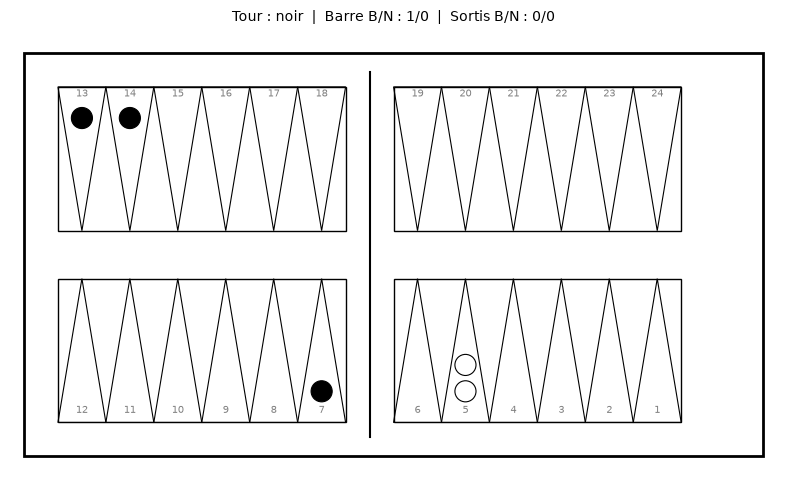


=== Tour 9 — blanc — dés : [2, 4] ===
Séquence jouée : [(-1, 1, 2), (4, 8, 4)]


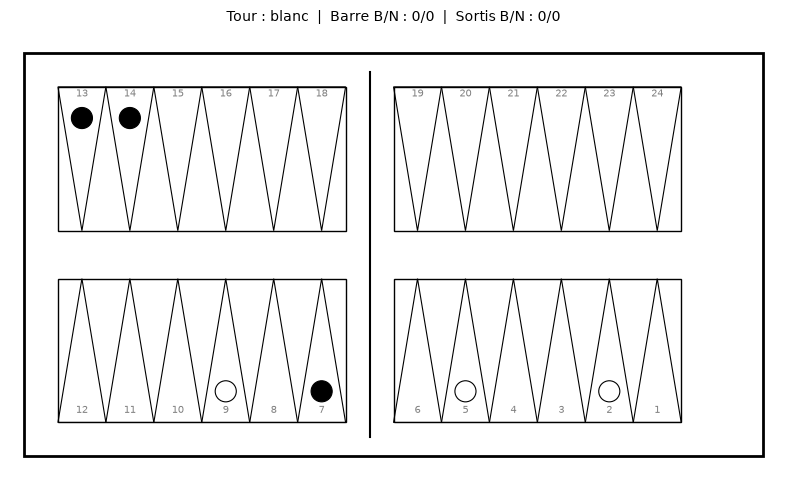


=== Tour 10 — noir — dés : [6, 6, 6, 6] ===
Séquence jouée : [(13, 7, 6), (6, 0, 6), (12, 6, 6), (7, 1, 6)]


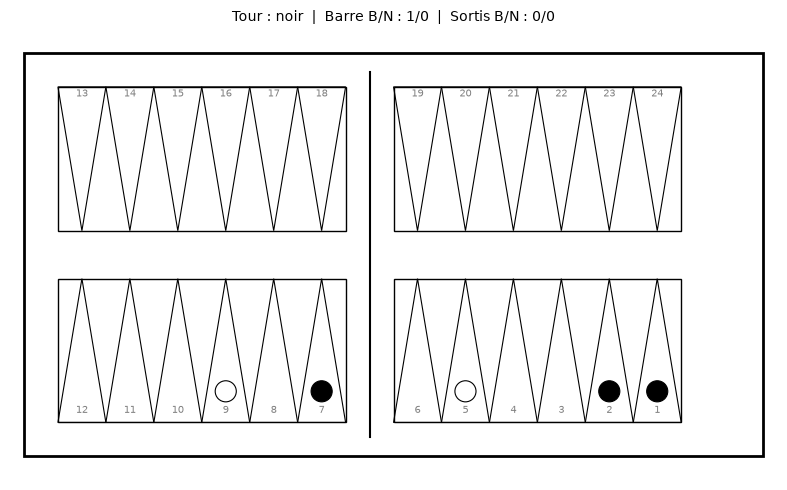


=== Tour 11 — blanc — dés : [6, 3] ===
Séquence jouée : [(-1, 5, 6), (8, 11, 3)]


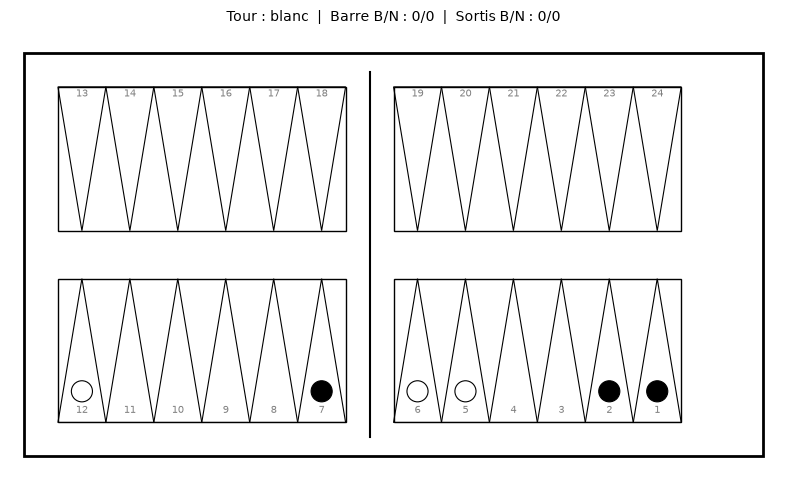


=== Tour 12 — noir — dés : [4, 1] ===
Séquence jouée : [(6, 2, 4), (2, 1, 1)]


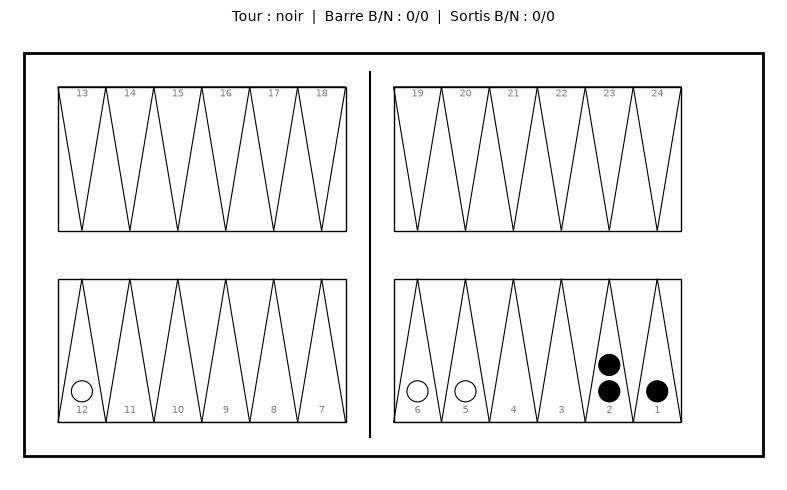


=== Tour 13 — blanc — dés : [5, 3] ===
Séquence jouée : [(11, 16, 5), (4, 7, 3)]


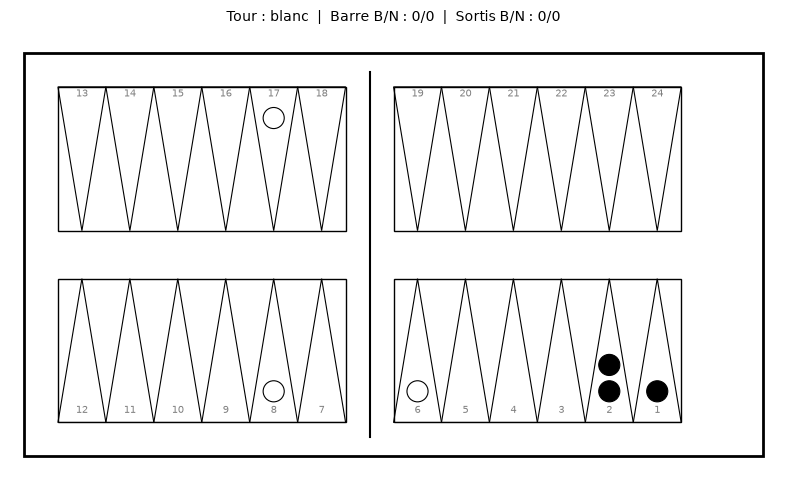


=== Tour 14 — noir — dés : [5, 1] ===
Séquence jouée : [(1, -1, 5), (0, -1, 1)]


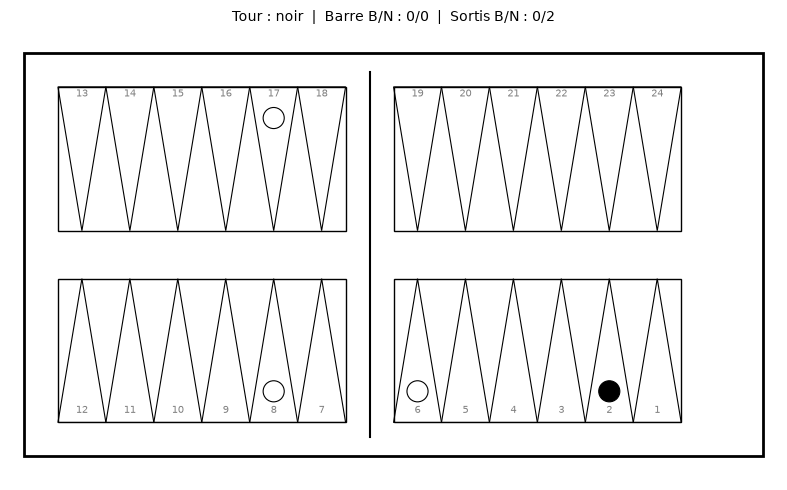


=== Tour 15 — blanc — dés : [2, 4] ===
Séquence jouée : [(5, 7, 2), (7, 11, 4)]


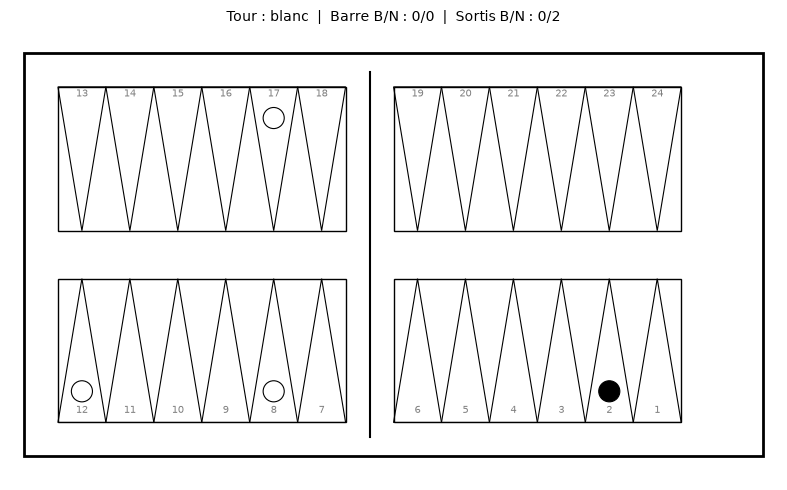


=== Tour 16 — noir — dés : [4, 6] ===
Séquence jouée : [(1, -1, 4)]


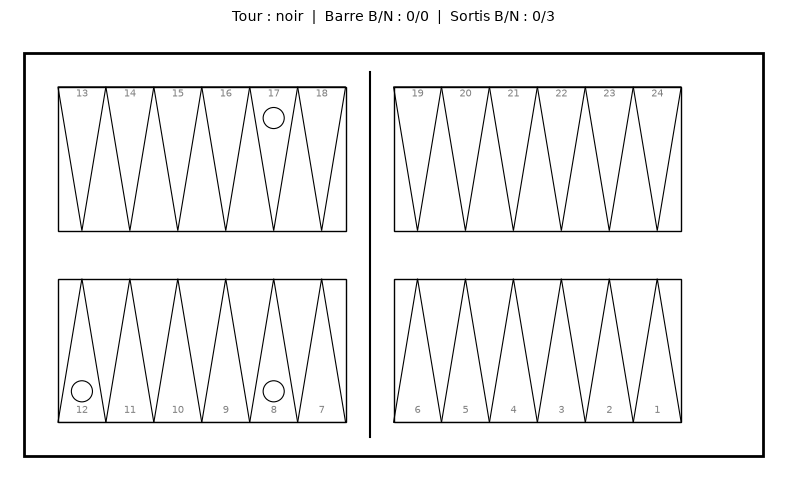


*** NOIR A GAGNÉ en 16 tours ***


In [9]:
def jouer_partie_tracee(n_tours=10):
    env = BackgammonEnv()
    env.reset()
    
    for tour in range(n_tours):
        des = lancer_des()
        print(f"\n=== Tour {tour + 1} — {env.joueur_actuel} — dés : {des} ===")
        
        sequences = env.coups_disponibles(des)
        
        if not sequences:
            print("Aucun coup possible, on passe.")
        else:
            seq = sequences[np.random.randint(len(sequences))]
            print("Séquence jouée :", seq)
            for (depart, arrivee, de) in seq:
                env.jouer_coup(depart, arrivee)
        
        fig, ax = afficher_plateau(env)
        plt.show()
        plt.close(fig)
        
        verifier_invariant(env)
        
        gagnant = env.partie_terminee()
        if gagnant:
            print(f"\n*** {gagnant.upper()} A GAGNÉ en {tour + 1} tours ***")
            return env
        
        env.changer_joueur()
    
    return env

env_test = jouer_partie_tracee(n_tours=25)

In [10]:
def jouer_partie_complete(max_tours=500):
    env = BackgammonEnv()
    env.reset()
    
    for tour in range(max_tours):
        des = lancer_des()
        sequences = env.coups_disponibles(des)
        
        if sequences:
            seq = sequences[np.random.randint(len(sequences))]
            for (depart, arrivee, de) in seq:
                env.jouer_coup(depart, arrivee)
        
        verifier_invariant(env)
        
        gagnant = env.partie_terminee()
        if gagnant:
            return tour + 1, gagnant
        
        env.changer_joueur()
    
    return max_tours, None

for i in range(5):
    n_tours, gagnant = jouer_partie_complete()
    print(f"Partie {i+1} : {n_tours} tours — gagnant : {gagnant}")

Partie 1 : 16 tours — gagnant : noir
Partie 2 : 24 tours — gagnant : noir
Partie 3 : 15 tours — gagnant : blanc
Partie 4 : 23 tours — gagnant : blanc
Partie 5 : 15 tours — gagnant : blanc
